### Vizualizations for Experiment 06 and 08.

- bin by ground truth likelihoods and by absolute deltas
- correlate exp06 and exp06-llama
- correlate exp06 and exp08
- correlate exp06/exp08 with success metrics

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
save_freq = 10
timings_qwen = { # approximate
    "qwen2.5_7b__grpo" : 1000 * save_freq,
    "qwen2.5_7b__kl-cov" : 1400 * save_freq,
    "qwen2.5_7b__dapo" : 2200 * save_freq,
    "qwen2.5_7b__grpo-s" : 1100 * save_freq
}
qwen_path = "/ptmp/rfechner/out/exp08"
qwen_methods = os.listdir(qwen_path)
qwen_rs_paths = list(filter(lambda x: x.startswith('reasoning_strategies'), qwen_methods))
qwen_rt_paths = list(filter(lambda x: x.startswith('reasoning_types'), qwen_methods))
qwen_es_paths = list(filter(lambda x: x.startswith('error_types'), qwen_methods))
qwen_es_paths_abs = [os.path.join(qwen_path, r) for r in qwen_es_paths]
qwen_rs_paths_abs = [os.path.join(qwen_path, r) for r in qwen_rs_paths]
qwen_rt_paths_abs = [os.path.join(qwen_path, r) for r in qwen_rt_paths]

In [146]:
def load(paths: list[str], ground_truth_t = -3, delta_t = 1) -> dict:
    per_methods = {}

    for path in paths:
        assert os.path.isdir(path)
        basename = os.path.basename(path)
        method = '__'.join(basename.split('__')[1:]) if '__' in basename else basename

        validation_dir_path = os.path.join(path, 'val_jsonl')
        precomp_files = [f for f in os.listdir(validation_dir_path) if f.endswith('_precomp.jsonl')]
        precomp_files = sorted(precomp_files, key=lambda x: int(x.split("_")[0]))

        checkpoints = []
        drop_p = []
        for pfile in precomp_files: # iterates over the checkpoints
            df = pd.read_json(os.path.join(validation_dir_path, pfile), lines=True)

            # Compute per-row means
            df['lpmean'] = df['logprobs'].apply(np.mean)
            df['entmean'] = df['entropy'].apply(np.mean)

            rows = []
            valid = 0
            for index, group_df in df.groupby('index'):
                # find anchor
                anchor_row = group_df[group_df['behaviour_type'] == 'anchor']
                other_rows = group_df[group_df['behaviour_type'] != 'anchor']
                lpdelta =  other_rows['lpmean'].to_numpy() - anchor_row['lpmean'].to_numpy()
                
                # filtering per checkpoint: Filter out indices which have unlikely anchor
                # or filter rows-per-index which have large delta distance to anchor
                if anchor_row['lpmean'].item() < ground_truth_t:
                    continue

                for bt, delta, behlp in zip(other_rows['behaviour_type'], lpdelta, other_rows['lpmean']):
                    if np.abs(delta) < delta_t:
                        rows.append({'behaviour_type': bt, 'lpgt': anchor_row['lpmean'].item(), 'lpdelta': delta, 'behlp' : behlp})
                        valid += 1
                    else:
                        rows.append({'behaviour_type': bt, 'lpgt': anchor_row['lpmean'].item(), 'lpdelta': np.nan, 'behlp' : behlp})
            # Create aggregated mean DataFrame
            new_df = pd.DataFrame(rows)
            checkpoints.append(new_df)
            drop_p.append(1 - valid / len(df))

        print(f'Path: {path}, Dropped {np.mean(drop_p) * 100:.2f} percent of rows on average.')
        per_methods[method] = checkpoints

    return per_methods

In [147]:
data = load(qwen_rt_paths_abs)

Path: /ptmp/rfechner/out/exp08/reasoning_types__qwen2.5_7b__kl-cov, Dropped 51.52 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_types__qwen2.5_7b__grpo, Dropped 48.40 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_types__qwen2.5_7b__grpo-s, Dropped 47.81 percent of rows on average.
Path: /ptmp/rfechner/out/exp08/reasoning_types__qwen2.5_7b__dapo, Dropped 47.12 percent of rows on average.


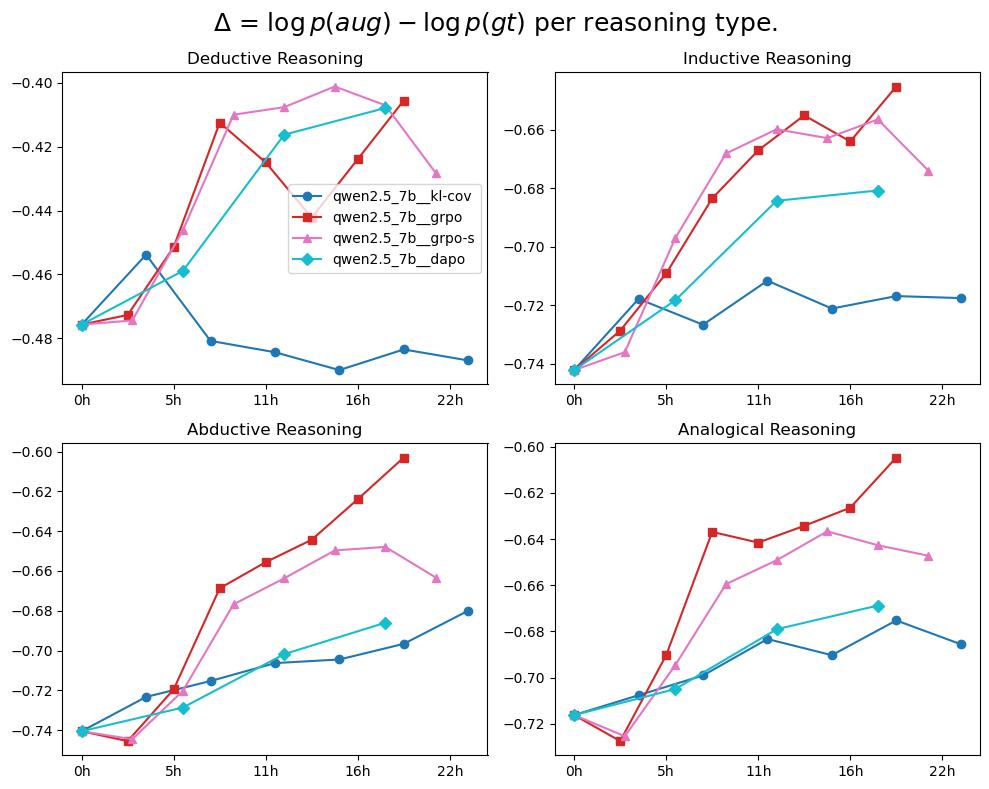

In [148]:
def plot(
    data: dict,
    behaviour_types : list[str],
    time_per_step_s: dict[str, int]
):

    methods = list(data.keys())
    n_behaviours = len(behaviour_types)
    
    # -------------------------------
    # Create figure
    # -------------------------------
    n_cols=2
    fig, axes = plt.subplots(
        figsize=(10 , 2 * n_behaviours),
        ncols=n_cols, nrows=int(np.ceil(n_behaviours / n_cols)),
        squeeze=False
    )

    axes = axes.flatten()
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    markers = ['o', 's', '^', 'D', 'x', 'v']

    behaviours = { b : {m : [] for m in methods} for b in behaviour_types}
    ground_truths = {m : [] for m in methods}
    
    # precompute plotting y-values
    for method, checkpoints_data in data.items():
        for df in checkpoints_data:
            for name, group in df.groupby('behaviour_type'):
                behaviours[name][method].append(np.nanmean(group['lpdelta']))
    
    for ax, beh in zip(axes, behaviour_types):
        for (method, values), color, marker in zip(behaviours[beh].items(), colors, markers):
            xs = np.arange(len(values)) * time_per_step_s[method]
            ax.plot(xs, values, label=method, marker=marker, color=color)
        ax.set_title(beh)

        x_seconds = np.arange(0, 90000, 20000)
        ax.set_xticks(x_seconds, [f"{int(h)}h" for h in (x_seconds // 3600)])
    axes[0].legend()

    fig.suptitle(f"$\\Delta$ = $\\log p (aug) - \\log p(gt)$ per reasoning type.", fontsize=18)
    plt.tight_layout()
    plt.show()
behaviour_types = data[list(data.keys())[0]][0]['behaviour_type'].unique()
plot(data, behaviour_types=behaviour_types, time_per_step_s=timings_qwen)

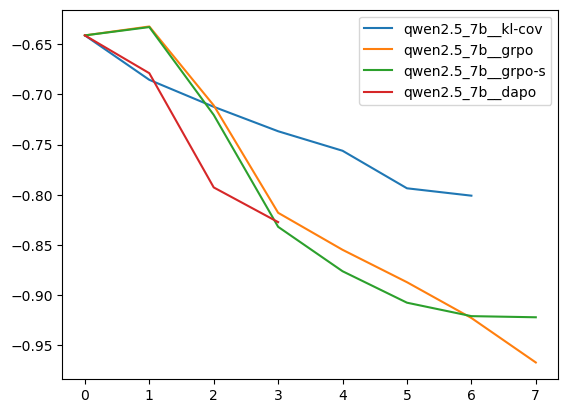

In [149]:
# just a quick plot to see whether the likelihood of the ground truths goes up.
def plot_likelihoods_gt(data : dict):
    gtlps = {method : [] for method in data.keys()}
    for method, checkpoints_data in data.items():
        for df in checkpoints_data:
            gtlps[method].append(df['lpgt'].mean())

    for method, means in gtlps.items():
        plt.plot(means, label=method)
    plt.legend()
    plt.show()

plot_likelihoods_gt(data)

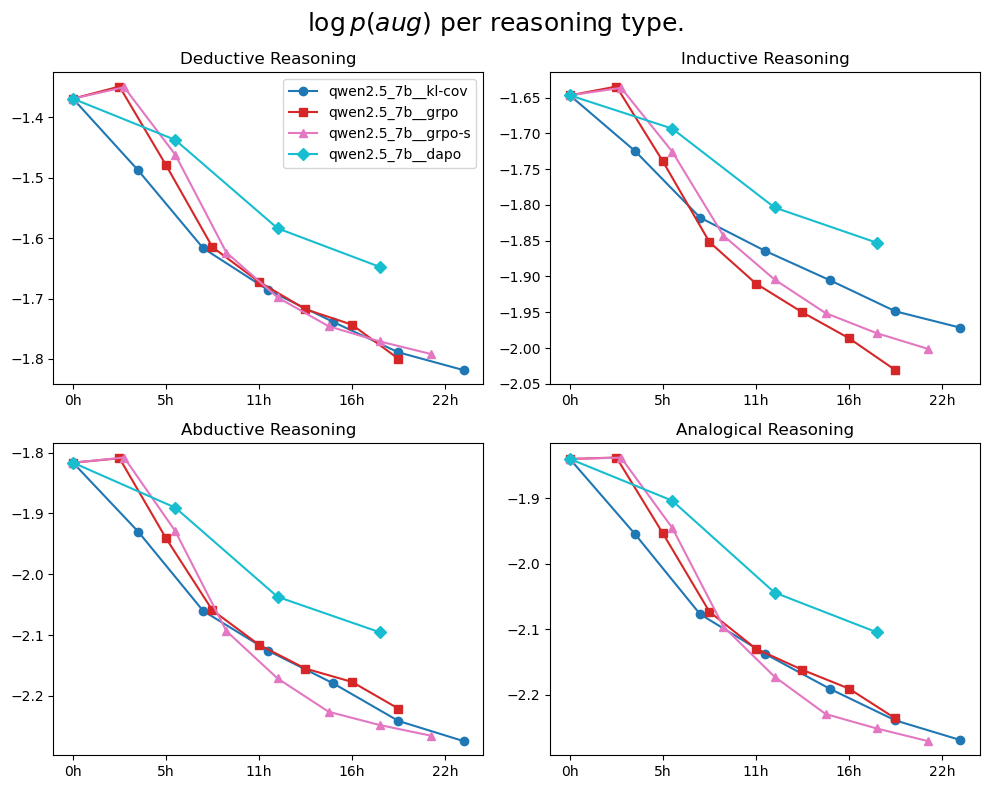

In [150]:
def plot2(
    data: dict,
    behaviour_types : list[str],
    time_per_step_s: dict[str, int]
):

    methods = list(data.keys())
    n_behaviours = len(behaviour_types)
    
    # -------------------------------
    # Create figure
    # -------------------------------
    n_cols=2
    fig, axes = plt.subplots(
        figsize=(10 , 2 * n_behaviours),
        ncols=n_cols, nrows=int(np.ceil(n_behaviours / n_cols)),
        squeeze=False
    )

    axes = axes.flatten()
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    markers = ['o', 's', '^', 'D', 'x', 'v']

    behaviours = { b : {m : [] for m in methods} for b in behaviour_types}
    ground_truths = {m : [] for m in methods}
    
    # precompute plotting y-values
    for method, checkpoints_data in data.items():
        for df in checkpoints_data:
            for name, group in df.groupby('behaviour_type'):
                behaviours[name][method].append(np.nanmean(group['behlp']))
    
    for ax, beh in zip(axes, behaviour_types):
        for (method, values), color, marker in zip(behaviours[beh].items(), colors, markers):
            xs = np.arange(len(values)) * time_per_step_s[method]
            ax.plot(xs, values, label=method, marker=marker, color=color)
        ax.set_title(beh)

        x_seconds = np.arange(0, 90000, 20000)
        ax.set_xticks(x_seconds, [f"{int(h)}h" for h in (x_seconds // 3600)])
    axes[0].legend()

    fig.suptitle(f"$\\log p (aug)$ per reasoning type.", fontsize=18)
    plt.tight_layout()
    plt.show()
behaviour_types = data[list(data.keys())[0]][0]['behaviour_type'].unique()
plot2(data, behaviour_types=behaviour_types, time_per_step_s=timings_qwen)